### Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score


### Load Dataset

In [2]:
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df.head()

,Child_age,BMI,Children_under5,Total_children_ever_born,Mother_age_current,Mother_education_1,Mother_education_2,Mother_education_3,Wealth_index_1,Wealth_index_2,...,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Child_sex_female,Father_education_1.0,Father_education_2.0,Father_education_3.0,Health_insurance_yes,Malnurished
0,17,22.00,1,1,34,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
1,40,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,0,1,0,0,0,1
2,59,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
3,55,21.53,1,1,28,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
4,14,28.03,1,1,26,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [3]:
df.shape

(2205, 37)

**Train-test Split**

In [4]:
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = 42)

In [5]:
print(y_train.value_counts())
print(y_test.value_counts())

Malnurished
0    1168
1     596
Name: count, dtype: int64
Malnurished
0    292
1    149
Name: count, dtype: int64


**Standard Scaler**

In [6]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

**Visualize the PCA Results**


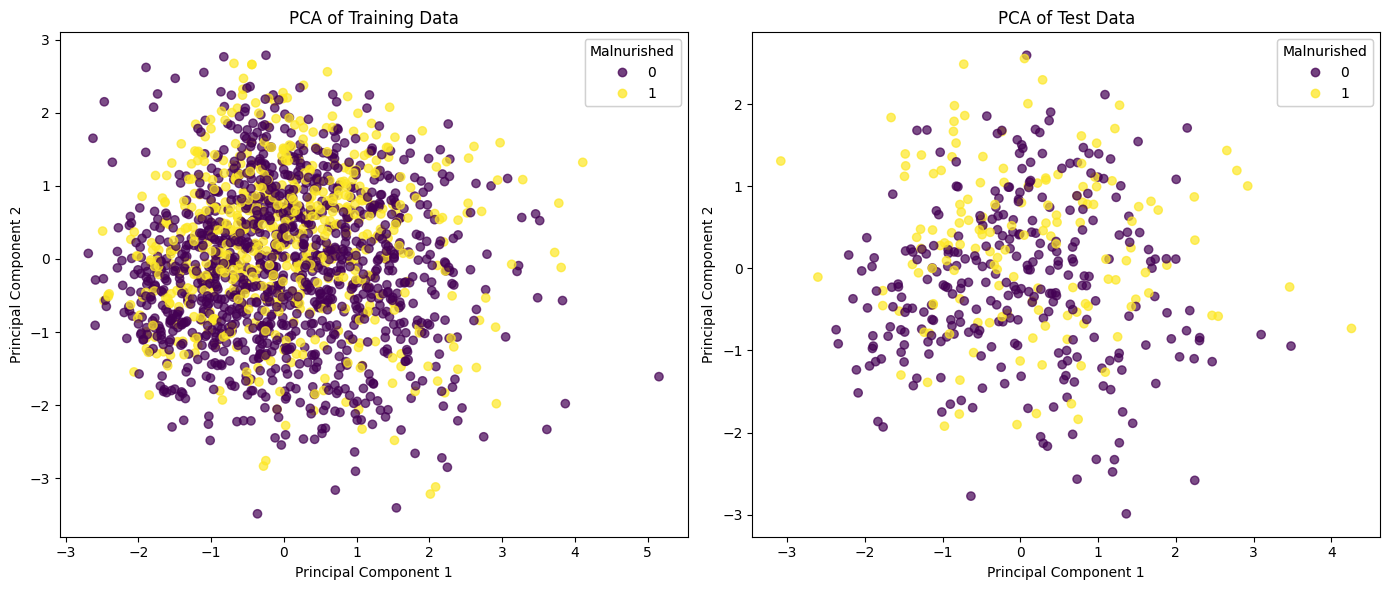

In [7]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for training data
scatter_train = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                                c=y_train, cmap='viridis', alpha=0.7)
axes[0].set_title("PCA of Training Data")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
legend1 = axes[0].legend(*scatter_train.legend_elements(), title="Malnurished")
axes[0].add_artist(legend1)

# Plot for test data
scatter_test = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                               c=y_test, cmap='viridis', alpha=0.7)
axes[1].set_title("PCA of Test Data")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
legend2 = axes[1].legend(*scatter_test.legend_elements(), title="Malnurished")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

## Model Fit

In [8]:
lr = LogisticRegression(class_weight='balanced', penalty=None, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_pred)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_pred)}\n')

Confusion Matrix: 
col_0          0    1
Malnurished          
0            171  121
1             52   97

Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.59      0.66       292
           1       0.44      0.65      0.53       149

    accuracy                           0.61       441
   macro avg       0.61      0.62      0.60       441
weighted avg       0.66      0.61      0.62       441




class_weight='balanced' is used instead of SMOTE for balancing the imbalanced classes

### Hyperparameter Tunning

In [9]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Set up GridSearchCV with recall as the scoring metric
grid_search = GridSearchCV(estimator=lr,
                           param_grid=param_grid,
                           cv=5,
                           scoring='recall',  # Optimize for recall
                           n_jobs=-1,
                           verbose=1)

# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train, y_train)

# Output best parameters based on recall
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best Hyperparameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}


**Model Fit With Best Parameters**

In [10]:
# Use the best estimator to make predictions on the test set
lr_best = grid_search.best_estimator_
probas = lr_best.predict(X_test)

print(classification_report(y_test, probas))

              precision    recall  f1-score   support

           0       0.76      0.49      0.59       292
           1       0.41      0.70      0.52       149

    accuracy                           0.56       441
   macro avg       0.58      0.59      0.55       441
weighted avg       0.64      0.56      0.57       441



### Threshold Adjustment

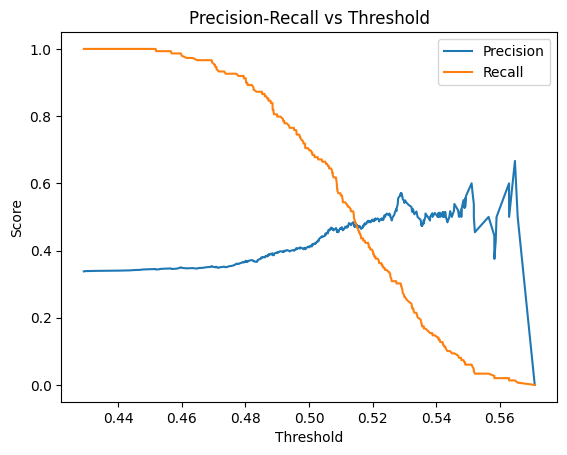

In [11]:
y_probas = lr_best.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()


In [12]:
y_probas = lr_best.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_probas_custom)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Confusion Matrix: 
col_0          1
Malnurished     
0            292
1            149

Classification Report: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       292
           1       0.34      1.00      0.51       149

    accuracy                           0.34       441
   macro avg       0.17      0.50      0.25       441
weighted avg       0.11      0.34      0.17       441




/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ROC curve

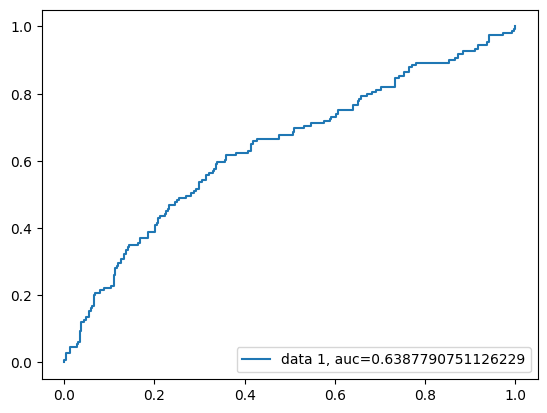

In [13]:
y_probas_custom = lr.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_probas_custom)
auc = metrics.roc_auc_score(y_test, y_probas_custom)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

**Extract feature coefficient and p-value**

In [20]:
import statsmodels.api as sm

# Add intercept to feature set
X_train_with_intercept = sm.add_constant(X_train)

# Fit logistic regression model using statsmodels
logit_model = sm.Logit(y_train, X_train_with_intercept)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.610003
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            Malnurished   No. Observations:                 1764
Model:                          Logit   Df Residuals:                     1727
Method:                           MLE   Df Model:                           36
Date:                Thu, 10 Apr 2025   Pseudo R-squ.:                 0.04629
Time:                        03:11:27   Log-Likelihood:                -1076.0
converged:                       True   LL-Null:                       -1128.3
Covariance Type:            nonrobust   LLR p-value:                 1.368e-08
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -0.7571      0.391     -1.937  

## Feature selection techniques

SelectKBest with the chi-square test

In [21]:

from sklearn.feature_selection import SelectKBest, chi2


# Use SelectKBest to select the top 10 features
selector = SelectKBest(chi2, k=18)
X_new = selector.fit_transform(X_train, y_train)

# Get the feature names
selected_features_chi = X_train.columns[selector.get_support()]

# Print the selected feature names
print(selected_features_chi)


ValueError: Input X must be non-negative.

In [ ]:
model_chi = LogisticRegression()
model_chi.fit(X_train[selected_features_chi], y_train)

y_pred_chi = model_chi.predict(X_test[selected_features_chi])
pd.crosstab(y_test, y_pred_chi)

In [ ]:
y_pred_chi = model_chi.predict(X_test[selected_features_chi])
pd.crosstab(y_test, y_pred_chi)
print(classification_report(y_test, y_pred_chi))

Stepwisse Features selection

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sfs_stepwise = SFS(model, 
                   k_features='best', 
                   forward=True, 
                   floating=True, 
                   scoring='accuracy', 
                   cv=5)

sfs_stepwise.fit(X_train, y_train)

# Selected features
print("Selected Features (Stepwise):", list(sfs_stepwise.k_feature_names_))


Religion_3 and Ethnicity_10 are perfectly correlated so Ethnicity_10 is removed

In [ ]:

selected_features_stepwise = ['Child_age', 'Mother_education', 'Wealth_index', 'Place_residence', 'BMI', 'Children_under5', 'Mother_age_at_first_birth', 
                              'Father_education', 'Region_3', 'Region_4', 'Region_7', 'Religion_3', 'Religion_4', 'Religion_5', 'Ethnicity_2', 
                              'Ethnicity_3', 'Ethnicity_5']

model_stepwise = LogisticRegression()
model_stepwise.fit(X_train[selected_features_stepwise], y_train)

y_pred_stepwise = model_stepwise.predict(X_test[selected_features_stepwise])
pd.crosstab(y_test, y_pred_stepwise)

In [ ]:
y_pred_stepwise = model_stepwise.predict(X_test[selected_features_stepwise])
pd.crosstab(y_test, y_pred_stepwise)
print(classification_report(y_test, y_pred_stepwise))

Recursive Feature Elimination with logistic regression


In [ ]:
from sklearn.feature_selection import RFE
# Use RFE to select the top 10 features
rfe = RFE(model, n_features_to_select=18)
rfe.fit(X_train, y_train)

# Print the selected features
selected_features_rfe = X_train.columns[rfe.support_]
print(selected_features_rfe)


In [ ]:

model_rfe = LogisticRegression()
model_rfe.fit(X_train[selected_features_rfe], y_train)


In [ ]:

y_pred_rfe = model_rfe.predict(X_test[selected_features_rfe])
pd.crosstab(y_test, y_pred_rfe)
y_pred_rfe = model_rfe.predict(X_test[selected_features_rfe])
pd.crosstab(y_test, y_pred_rfe)
print(classification_report(y_test, y_pred_rfe))

In [ ]:
# from sklearn import metrics
# import matplotlib.pyplot as plt
# y_pred_ref = model_rfe.predict_proba(X_test[selected_features_rfe])[::,1]
# fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_rfe)
# auc = metrics.roc_auc_score(y_test, y_pred_rfe)
# plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
# plt.legend(loc=4)
# plt.show()